In [ ]:
pip install pandas numpy matplotlib pillow scikit-learn tensorflow streamlit opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 86.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define paths based on your screenshot
zip_path = '/content/drive/My Drive/GlaucomaProject/Images.zip'
csv_path = '/content/drive/My Drive/GlaucomaProject/Labels.csv'
extract_dir = '/content/dataset'

# 3. Unzip the images into Colab's local environment (much faster for training)
import zipfile
print("Extracting images...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("Extraction complete!")

# Check exactly what folder the images extracted into
print("Files in extraction directory:", os.listdir(extract_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting images...
Extraction complete!
Files in extraction directory: ['Images']


In [ ]:
import pandas as pd
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# 1. Read the CSV
df = pd.read_csv(csv_path)

FILENAME_COLUMN = 'Image Name'
LABEL_COLUMN = 'Label'

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

print("===== DATASET OVERVIEW =====")

print("\nDataset shape:", df.shape)
print("\nColumns:", df.columns)

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

===== DATASET OVERVIEW =====

Dataset shape: (747, 5)

Columns: Index(['Image Name', 'Patient', 'Label', 'Quality Score', 'Unnamed: 4'], dtype='object')

First 5 rows:
  Image Name  Patient Label  Quality Score  Unnamed: 4
0    0_0.jpg        0  GON+           6.18         NaN
1    1_0.jpg        1  GON+           5.31         NaN
2    1_1.jpg        1  GON+           4.37         NaN
3    2_0.jpg        2  GON+           3.51         NaN
4    2_1.jpg        2  GON+           4.24         NaN

Missing values:
Image Name         0
Patient            0
Label              0
Quality Score      0
Unnamed: 4       747
dtype: int64



===== LABEL DISTRIBUTION =====
Label
GON+    548
GON-    199
Name: count, dtype: int64


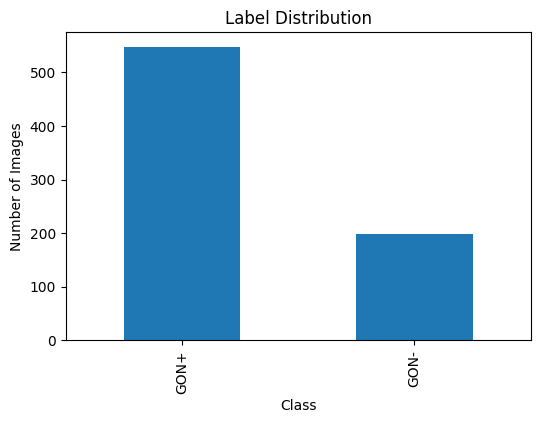

In [ ]:
# ---------------------------------------------------
# LABEL DISTRIBUTION
# ---------------------------------------------------

print("\n===== LABEL DISTRIBUTION =====")

label_counts = df[LABEL_COLUMN].value_counts()

print(label_counts)

plt.figure(figsize=(6,4))
label_counts.plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
# ---------------------------------------------------
# PATIENT ANALYSIS (IF COLUMN EXISTS)
# ---------------------------------------------------

if "Patient" in df.columns:

    print("\n===== PATIENT ANALYSIS =====")

    print("Total images:", len(df))
    print("Unique patients:", df["Patient"].nunique())

    print("\nImages per patient:")
    print(df.groupby("Patient").size().head())



===== PATIENT ANALYSIS =====
Total images: 747
Unique patients: 288

Images per patient:
Patient
0    1
1    2
2    2
3    2
4    1
dtype: int64



===== QUALITY SCORE ANALYSIS =====
count    747.000000
mean       5.904311
std        1.007189
min        2.040000
25%        5.365000
50%        6.180000
75%        6.630000
max        7.690000
Name: Quality Score, dtype: float64


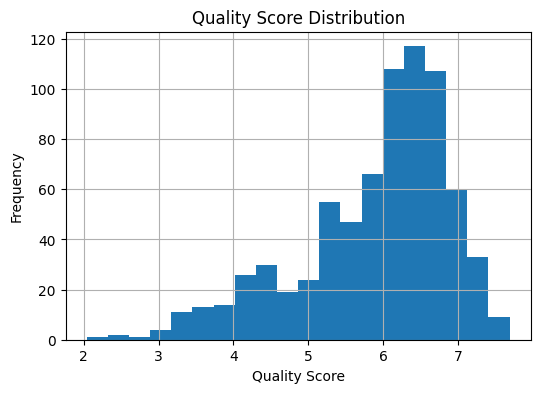


Filtering images with Quality Score < 5
Images before filtering: 747
Images after filtering: 618


In [ ]:
# ---------------------------------------------------
# QUALITY SCORE ANALYSIS
# ---------------------------------------------------

if "Quality Score" in df.columns:

    print("\n===== QUALITY SCORE ANALYSIS =====")

    print(df["Quality Score"].describe())

    plt.figure(figsize=(6,4))
    df["Quality Score"].hist(bins=20)
    plt.title("Quality Score Distribution")
    plt.xlabel("Quality Score")
    plt.ylabel("Frequency")
    plt.show()

    # Filter low quality images
    QUALITY_THRESHOLD = 5

    print(f"\nFiltering images with Quality Score < {QUALITY_THRESHOLD}")

    before = len(df)

    df = df[df["Quality Score"] >= QUALITY_THRESHOLD]

    after = len(df)

    print("Images before filtering:", before)
    print("Images after filtering:", after)

In [ ]:
# ---------------------------------------------------
# LABEL ENCODING
# ---------------------------------------------------

print("\n===== ENCODING LABELS =====")

label_map = {
    "GON+":1,
    "GON-":0
}

if df[LABEL_COLUMN].dtype == "object":
    df["label_numeric"] = df[LABEL_COLUMN].map(label_map)
else:
    df["label_numeric"] = df[LABEL_COLUMN]

print(df[[LABEL_COLUMN,"label_numeric"]].head())


===== ENCODING LABELS =====
  Label  label_numeric
0  GON+              1
1  GON+              1
5  GON+              1
7  GON+              1
8  GON+              1


In [ ]:
# ---------------------------------------------------
# IMAGE EXISTENCE CHECK
# ---------------------------------------------------

print("\n===== IMAGE FILE CHECK =====")
actual_image_dir = "/content/dataset/Images"
missing_images = []

for img_name in df[FILENAME_COLUMN]:

    img_path = os.path.join(actual_image_dir, img_name)

    if not os.path.exists(img_path):
        missing_images.append(img_name)

print("Missing images:", len(missing_images))

if len(missing_images) > 0:
    print("Example missing files:", missing_images[:10])


===== IMAGE FILE CHECK =====
Missing images: 0


In [ ]:
# ---------------------------------------------------
# IMAGE SIZE INSPECTION
# ---------------------------------------------------

print("\n===== IMAGE SIZE INSPECTION =====")

sizes = []

sample_images = df[FILENAME_COLUMN].sample(20)

for img_name in sample_images:

    img_path = os.path.join(actual_image_dir, img_name)

    if os.path.exists(img_path):

        img = Image.open(img_path)

        sizes.append(img.size)

print("Sample image sizes:", sizes)

print("Unique sizes:", set(sizes))


===== IMAGE SIZE INSPECTION =====
Sample image sizes: [(1889, 1889), (1895, 1895), (1881, 1881), (1898, 1898), (1878, 1878), (1877, 1877), (1909, 1909), (1881, 1881), (1911, 1911), (1915, 1915), (1878, 1878), (1890, 1890), (1878, 1878), (1903, 1903), (1894, 1894), (1890, 1890), (1920, 1920), (1911, 1911), (1890, 1890), (1898, 1898)]
Unique sizes: {(1881, 1881), (1898, 1898), (1909, 1909), (1890, 1890), (1903, 1903), (1895, 1895), (1877, 1877), (1911, 1911), (1915, 1915), (1920, 1920), (1894, 1894), (1889, 1889), (1878, 1878)}



===== DISPLAY SAMPLE RETINAL IMAGES =====


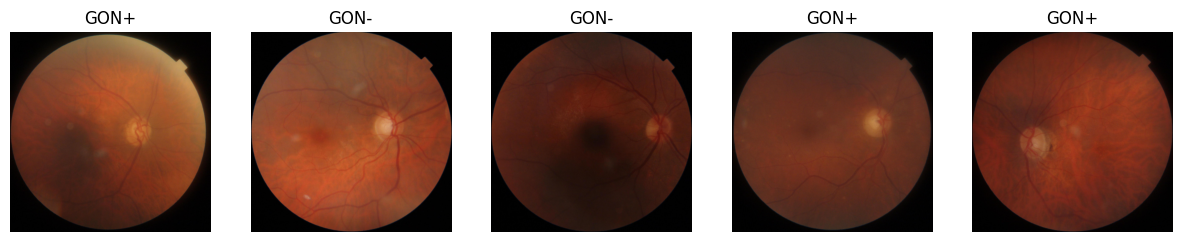

In [ ]:
# ---------------------------------------------------
# SHOW SAMPLE IMAGES
# ---------------------------------------------------

print("\n===== DISPLAY SAMPLE RETINAL IMAGES =====")

plt.figure(figsize=(15,5))

samples = df.sample(5)

for i,(idx,row) in enumerate(samples.iterrows()):

    img_path = os.path.join(actual_image_dir,row[FILENAME_COLUMN])

    img = Image.open(img_path)

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.title(row[LABEL_COLUMN])

    plt.axis("off")

plt.show()

In [ ]:
# ---------------------------------------------------
# CLASS IMBALANCE CHECK
# ---------------------------------------------------

print("\n===== CLASS IMBALANCE CHECK =====")

total = len(df)

for label,count in label_counts.items():

    percentage = count/total*100

    print(f"{label}: {count} ({percentage:.2f}%)")


===== CLASS IMBALANCE CHECK =====
GON+: 548 (88.67%)
GON-: 199 (32.20%)


In [ ]:
print("Dataset shape:", df.shape)
print("\nColumns in dataset:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (618, 6)

Columns in dataset:
Index(['Image Name', 'Patient', 'Label', 'Quality Score', 'Unnamed: 4',
       'label_numeric'],
      dtype='object')

First 5 rows:
  Image Name  Patient Label  Quality Score  Unnamed: 4  label_numeric
0    0_0.jpg        0  GON+           6.18         NaN              1
1    1_0.jpg        1  GON+           5.31         NaN              1
5    3_0.jpg        3  GON+           5.95         NaN              1
7    4_0.jpg        4  GON+           5.25         NaN              1
8    5_0.jpg        5  GON+           6.58         NaN              1

Missing values:
Image Name         0
Patient            0
Label              0
Quality Score      0
Unnamed: 4       618
label_numeric      0
dtype: int64



Label Distribution:
Label
GON+    439
GON-    179
Name: count, dtype: int64


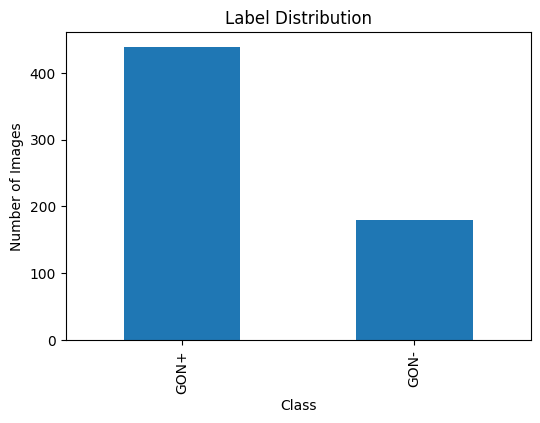

In [ ]:
import matplotlib.pyplot as plt

label_counts = df[LABEL_COLUMN].value_counts()

print("\nLabel Distribution:")
print(label_counts)

plt.figure(figsize=(6,4))
label_counts.plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
if "Quality Score" in df.columns:

    print("\nQuality score statistics:")
    print(df["Quality Score"].describe())

    QUALITY_THRESHOLD = 5

    before = len(df)

    df = df[df["Quality Score"] >= QUALITY_THRESHOLD]

    after = len(df)

    print("\nImages before filtering:", before)
    print("Images after filtering:", after)


Quality score statistics:
count    618.000000
mean       6.278333
std        0.584024
min        5.000000
25%        5.880000
50%        6.310000
75%        6.700000
max        7.690000
Name: Quality Score, dtype: float64

Images before filtering: 618
Images after filtering: 618


In [ ]:
label_map = {
    "GON+":1,
    "GON-":0
}

df["label_numeric"] = df[LABEL_COLUMN].map(label_map)

print("\nEncoded Labels:")
print(df[[LABEL_COLUMN,"label_numeric"]].head())


Encoded Labels:
  Label  label_numeric
0  GON+              1
1  GON+              1
5  GON+              1
7  GON+              1
8  GON+              1


In [ ]:
missing_files = []

for img in df[FILENAME_COLUMN]:

    path = os.path.join(actual_image_dir, img)

    if not os.path.exists(path):
        missing_files.append(img)

print("Missing images:", len(missing_files))

Missing images: 0


In [ ]:
from sklearn.model_selection import train_test_split

# First split: Train vs Temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df[LABEL_COLUMN],
    random_state=42
)

# Second split: Validation vs Test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df[LABEL_COLUMN],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 432
Validation size: 93
Test size: 93


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=actual_image_dir,
    x_col=FILENAME_COLUMN,
    y_col=LABEL_COLUMN,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 432 validated image filenames belonging to 2 classes.


In [ ]:
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=actual_image_dir,
    x_col=FILENAME_COLUMN,
    y_col=LABEL_COLUMN,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 93 validated image filenames belonging to 2 classes.


In [ ]:
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=actual_image_dir,
    x_col=FILENAME_COLUMN,
    y_col=LABEL_COLUMN,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 93 validated image filenames belonging to 2 classes.


In [ ]:
print("\nGenerator Summary")

print("Training batches:", train_generator.samples)
print("Validation batches:", val_generator.samples)
print("Test batches:", test_generator.samples)


Generator Summary
Training batches: 432
Validation batches: 93
Test batches: 93


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

#Training  callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

checkpoint_custom = ModelCheckpoint(
    "best_custom_model.h5",
    monitor="val_loss",
    save_best_only=True
)

checkpoint_pretrained = ModelCheckpoint(
    "best_pretrained_model.h5",
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
#custom model
from tensorflow.keras import layers, models

custom_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

custom_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

custom_model.summary()

print("Training Custom Model...")

history_custom = custom_model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, checkpoint_custom]
)

print("Evaluating Custom Model on Test Data")

test_loss_custom, test_acc_custom = custom_model.evaluate(test_generator)

print("Custom Model Test Accuracy:", test_acc_custom)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

...

14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 958ms/step - accuracy: 0.8426 - loss: 0.3616 - val_accuracy: 0.9570 - val_loss: 0.1919 - learning_rate: 0.0010
Epoch 5/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 913ms/step - accuracy: 0.8681 - loss: 0.3195 - val_accuracy: 0.9032 - val_loss: 0.3305 - learning_rate: 0.0010
Epoch 6/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 935ms/step - accuracy: 0.9028 - loss: 0.2738 - val_accuracy: 0.9355 - val_loss: 0.2405 - learning_rate: 0.0010
Epoch 7/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.9122 - loss: 0.2504

14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 949ms/step - accuracy: 0.9120 - loss: 0.2443 - val_accuracy: 0.9462 - val_loss: 0.1909 - learning_rate: 0.0010
Epoch 8/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 729ms/step - accuracy: 0.9434 - loss: 0.1695

14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 934ms/step - accuracy: 0.9329 - loss: 0.2244 - val_accuracy: 0.9570 - val_loss: 0.1717 - learning_rate: 0.0010
Epoch 9/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 905ms/step - accuracy: 0.9282 - loss: 0.1965 - val_accuracy: 0.9462 - val_loss: 0.1820 - learning_rate: 0.0010
Epoch 10/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 910ms/step - accuracy: 0.9144 - loss: 0.2284 - val_accuracy: 0.9570 - val_loss: 0.1722 - learning_rate: 0.0010
Epoch 11/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 824ms/step - accuracy: 0.9167 - loss: 0.2350 - val_accuracy: 0.9570 - val_loss: 0.1735 - learning_rate: 0.0010
Epoch 12/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 968ms/step - accuracy: 0.9306 - loss: 0.2162 - val_accuracy: 0.9462 - val_loss: 0.1740 - learning_rate: 3.0000e-04
Epoch 13/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.9524 - loss: 0.2008

14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 948ms/step - accuracy: 0.9398 - loss: 0.2277 - val_accuracy: 0.9570 - val_loss: 0.1716 - learning_rate: 3.0000e-04
Epoch 14/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.9496 - loss: 0.1596

14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 953ms/step - accuracy: 0.9306 - loss: 0.1975 - val_accuracy: 0.9570 - val_loss: 0.1678 - learning_rate: 3.0000e-04
Epoch 15/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 910ms/step - accuracy: 0.9375 - loss: 0.1951 - val_accuracy: 0.9570 - val_loss: 0.1684 - learning_rate: 3.0000e-04
Evaluating Custom Model on Test Data
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 426ms/step - accuracy: 0.9570 - loss: 0.1202
Custom Model Test Accuracy: 0.9569892287254333


In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

pretrained_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

pretrained_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

pretrained_model.summary()

print("Training Pre-trained Model...")

history_pretrained = pretrained_model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[reduce_lr, checkpoint_pretrained] # Removed early_stop to ensure all epochs run
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training Pre-trained Model...
Epoch 1/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.7778 - loss: 0.5123 - val_accuracy: 0.9355 - val_loss: 0.2248 - learning_rate: 0.0010
Epoch 2/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 936ms/step - accuracy: 0.8727 - loss: 0.3249 - val_accuracy: 0.9247 - val_loss: 0.1906 - learning_rate: 0.0010
Epoch 3/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 941ms/step - accuracy: 0.9005 - loss: 0.2452 - val_accuracy: 0.9355 - val_loss: 0.1912 - learning_rate: 0.0010
Epoch 4/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.9190 - loss: 0.2157

14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 956ms/step - accuracy: 0.9097 - loss: 0.2212 - val_accuracy: 0.9462 - val_loss: 0.1682 - learning_rate: 3.0000e-04
Epoch 5/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 902ms/step - accuracy: 0.9074 - loss: 0.2335 - val_accuracy: 0.9570 - val_loss: 0.1730 - learning_rate: 3.0000e-04
Epoch 6/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.9335 - loss: 0.1737

14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 836ms/step - accuracy: 0.9259 - loss: 0.1940 - val_accuracy: 0.9570 - val_loss: 0.1676 - learning_rate: 3.0000e-04
Epoch 7/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 867ms/step - accuracy: 0.9236 - loss: 0.2098 - val_accuracy: 0.9355 - val_loss: 0.1750 - learning_rate: 3.0000e-04
Epoch 8/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - accuracy: 0.9262 - loss: 0.2134

14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 962ms/step - accuracy: 0.9306 - loss: 0.1959 - val_accuracy: 0.9570 - val_loss: 0.1611 - learning_rate: 3.0000e-04
Epoch 9/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 906ms/step - accuracy: 0.9259 - loss: 0.1961 - val_accuracy: 0.9570 - val_loss: 0.1656 - learning_rate: 3.0000e-04
Epoch 10/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 932ms/step - accuracy: 0.9306 - loss: 0.1706 - val_accuracy: 0.9570 - val_loss: 0.1628 - learning_rate: 3.0000e-04
Epoch 11/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 933ms/step - accuracy: 0.9444 - loss: 0.1909 - val_accuracy: 0.9247 - val_loss: 0.1798 - learning_rate: 3.0000e-04
Epoch 12/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 924ms/step - accuracy: 0.9491 - loss: 0.1663 - val_accuracy: 0.9462 - val_loss: 0.1707 - learning_rate: 9.0000e-05
Epoch 13/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 950ms/step - accuracy: 0.9398 - loss: 0.1611 - val_accuracy: 0.9462 - val_loss: 0.1700 - learning_rate: 9.0000e-05
Epoch 14/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 914ms/step - accuracy:

In [ ]:
print("Evaluating Pretrained Model on Test Data")

test_loss_pre, test_acc_pre = pretrained_model.evaluate(test_generator)

print("Pretrained Model Test Accuracy:", test_acc_pre)

Evaluating Pretrained Model on Test Data
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 444ms/step - accuracy: 0.9032 - loss: 0.2448
Pretrained Model Test Accuracy: 0.9032257795333862


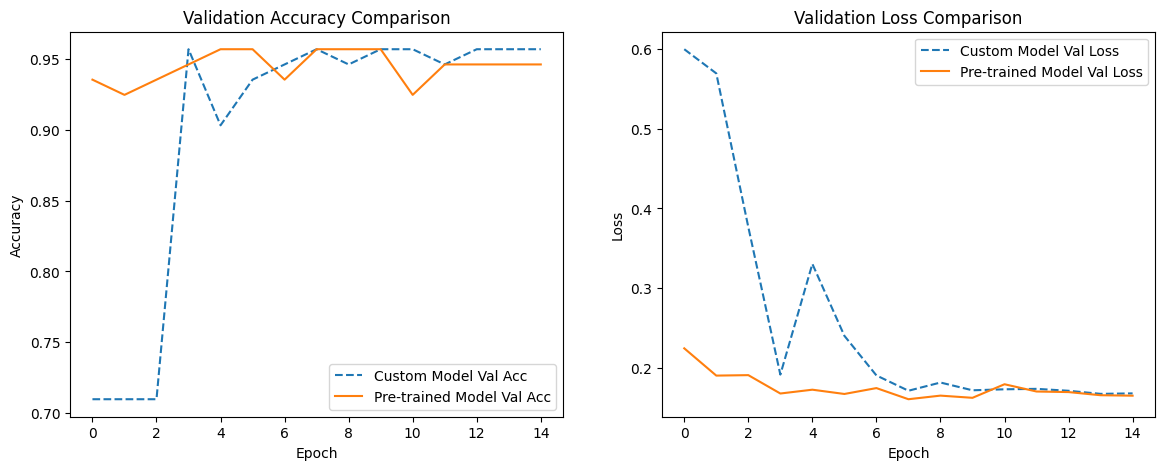

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history_custom, history_pretrained):
    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history_custom.history['val_accuracy'], label='Custom Model Val Acc', linestyle='--')
    plt.plot(history_pretrained.history['val_accuracy'], label='Pre-trained Model Val Acc')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history_custom.history['val_loss'], label='Custom Model Val Loss', linestyle='--')
    plt.plot(history_pretrained.history['val_loss'], label='Pre-trained Model Val Loss')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history_custom, history_pretrained)

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def compute_saliency_map(model, img_array, class_index=0):
    """
    Computes the vanilla saliency map for a given image.
    """
    img_tensor = tf.convert_to_tensor(img_array)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        # Get the model prediction
        predictions = model(img_tensor)
        # For binary classification (sigmoid), we take the value directly
        # If it were categorical (softmax), we'd take predictions[:, class_index]
        loss = predictions[0]

    # Calculate the gradients of the loss with respect to the image
    grads = tape.gradient(loss, img_tensor)

    # Take the maximum absolute gradient across the color channels
    # This results in a 2D heatmap
    saliency = tf.reduce_max(tf.abs(grads), axis=-1)

    # Normalize to 0-1 range for visualization
    saliency = (saliency - tf.reduce_min(saliency)) / (tf.reduce_max(saliency) - tf.reduce_min(saliency))

    return saliency.numpy()[0]

def plot_saliency(model, generator, model_name="Model"):
    # 1. Grab a batch from the validation generator
    images, labels = next(generator)

    # 2. Pick the first image in the batch
    img = images[0]
    label = labels[0]
    img_input = np.expand_dims(img, axis=0) # Add batch dimension

    # 3. Get prediction
    pred = model.predict(img_input)[0][0]
    pred_label = "Glaucoma" if pred > 0.5 else "Normal"
    actual_label = "Glaucoma" if label > 0.5 else "Normal"

    # 4. Compute Saliency
    saliency = compute_saliency_map(model, img_input)

    # 5. Visualize
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Original Image\nActual: {actual_label}")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(saliency, cmap='hot')
    plt.title(f"Saliency Map ({model_name})\nPredicted: {pred_label} ({pred:.2f})")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(saliency, cmap='hot', alpha=0.5) # Overlay
    plt.title("Overlay")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Visualizing Custom Model Interpretability:
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


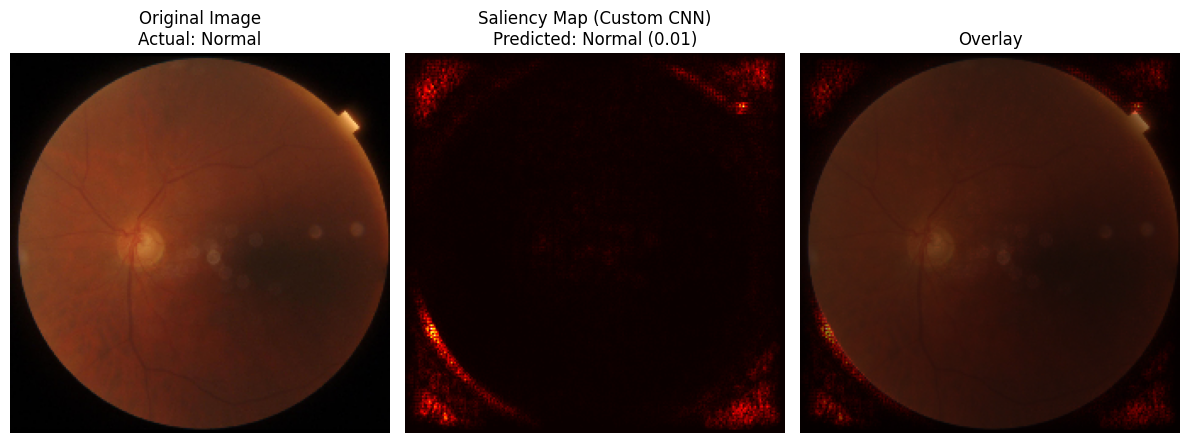

Visualizing Pre-trained Model Interpretability:
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


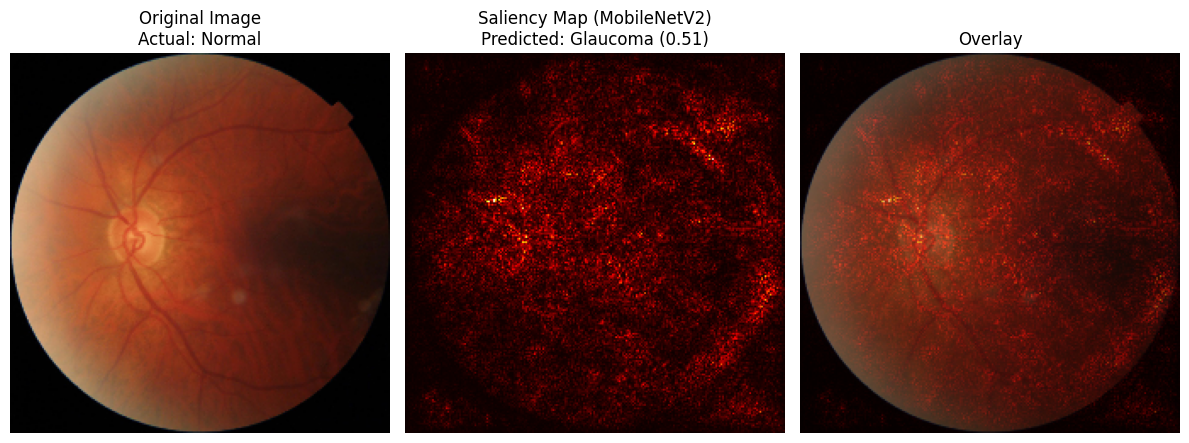

In [ ]:
# Saliency for Custom Model
print("Visualizing Custom Model Interpretability:")
plot_saliency(custom_model, val_generator, model_name="Custom CNN")

# Saliency for Pre-trained Model (MobileNetV2)
print("Visualizing Pre-trained Model Interpretability:")
plot_saliency(pretrained_model, val_generator, model_name="MobileNetV2")

### Occlusion Sensitivity for Custom CNN Model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


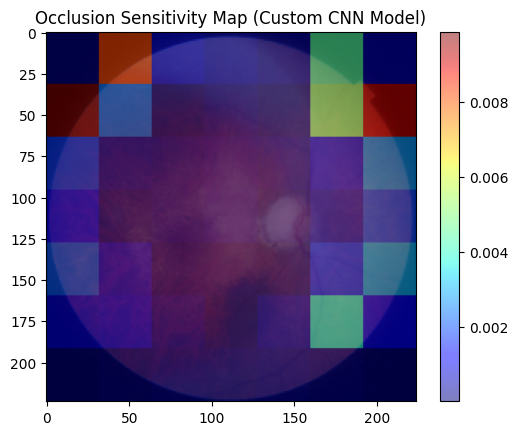

In [ ]:
# Get an image from the generator
img_for_occlusion_custom = next(val_generator)[0][0]

# Run occlusion sensitivity for custom model
occ_heatmap_custom = occlusion_sensitivity(custom_model, img_for_occlusion_custom)

plt.imshow(img_for_occlusion_custom)
plt.imshow(occ_heatmap_custom, cmap='jet', alpha=0.5)
plt.title("Occlusion Sensitivity Map (Custom CNN Model)")
plt.colorbar()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


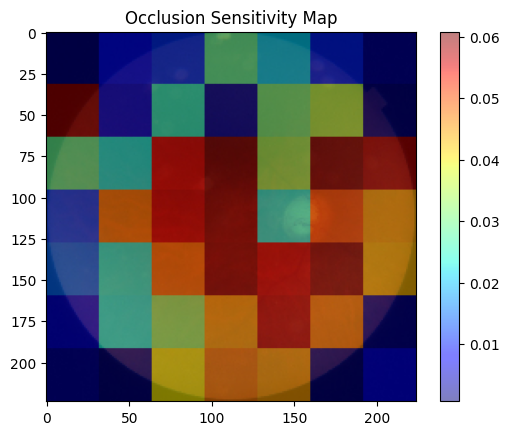

In [ ]:
def occlusion_sensitivity(model, img, patch_size=32):
    img_size = img.shape[0]
    heatmap = np.zeros((img_size, img_size))

    # Get baseline prediction
    baseline_prob = model.predict(np.expand_dims(img, axis=0))[0][0]

    for i in range(0, img_size, patch_size):
        for j in range(0, img_size, patch_size):
            # Create a copy and occlude a patch
            img_occluded = img.copy()
            img_occluded[i:i+patch_size, j:j+patch_size, :] = 0 # Black patch

            # Predict
            prob = model.predict(np.expand_dims(img_occluded, axis=0), verbose=0)[0][0]

            # The more the probability changes, the more important the patch
            heatmap[i:i+patch_size, j:j+patch_size] = np.abs(baseline_prob - prob)

    return heatmap

# Run it
img = next(val_generator)[0][0]
occ_heatmap = occlusion_sensitivity(pretrained_model, img)

plt.imshow(img)
plt.imshow(occ_heatmap, cmap='jet', alpha=0.5)
plt.title("Occlusion Sensitivity Map")
plt.colorbar()
plt.show()